In [12]:
pip install cartopy


   ---------------------------------------- 0.0/11.0 MB ? eta -:--:--
    --------------------------------------- 0.3/11.0 MB ? eta -:--:--
   -- ------------------------------------- 0.8/11.0 MB 2.1 MB/s eta 0:00:05
   ---- ----------------------------------- 1.3/11.0 MB 2.3 MB/s eta 0:00:05
   ------ --------------------------------- 1.8/11.0 MB 2.1 MB/s eta 0:00:05
   -------- ------------------------------- 2.4/11.0 MB 2.3 MB/s eta 0:00:04
   --------- ------------------------------ 2.6/11.0 MB 2.2 MB/s eta 0:00:04
   ----------- ---------------------------- 3.1/11.0 MB 2.1 MB/s eta 0:00:04
   ------------- -------------------------- 3.7/11.0 MB 2.2 MB/s eta 0:00:04
   --------------- ------------------------ 4.2/11.0 MB 2.2 MB/s eta 0:00:04
   ------------------ --------------------- 5.0/11.0 MB 2.4 MB/s eta 0:00:03
   --------------------- ------------------ 5.8/11.0 MB 2.5 MB/s eta 0:00:03
   ----------------------- ---------------- 6.6/11.0 MB 2.6 MB/s eta 0:00:02
   ----------

### CEREALS 

## Maize

In [2]:
import os
import glob
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import dask.array as da

In [3]:
ds = xr.open_dataset(r"C:\Users\paola\Tesis\01_Data\CEREALS\gdhy_v1.2_v1.3_20190128\maize\yield_1982.nc4")

In [3]:
ds

<xarray.Dataset> Size: 1MB
Dimensions:  (lon: 720, lat: 360)
Coordinates:
  * lon      (lon) float64 6kB 0.25 0.75 1.25 1.75 ... 358.2 358.8 359.2 359.8
  * lat      (lat) float64 3kB -89.75 -89.25 -88.75 -88.25 ... 88.75 89.25 89.75
Data variables:
    var      (lat, lon) float32 1MB ...

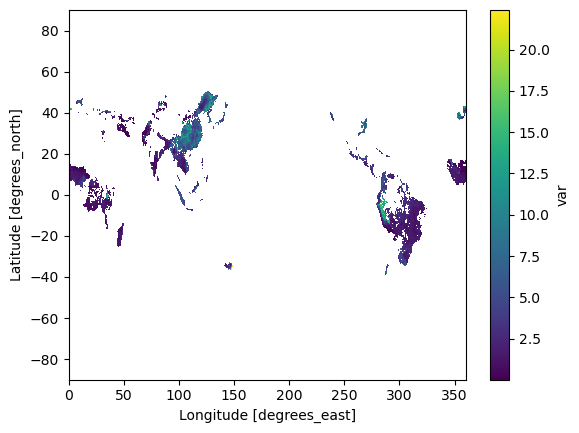

In [4]:
ds.get("var").plot()

### Eliminación de tendencia en series de rendimiento

Con el fin de aislar la señal climática de los rendimientos agrícolas, se aplica un **detrending estadístico** a las series anuales de rendimiento por píxel.  
El procedimiento consiste en ajustar una **regresión lineal del rendimiento en función del tiempo**:

\[
Y_{i,j,t} = \alpha_{i,j} + \beta_{i,j} t + \varepsilon_{i,j,t}
\]

donde:
- \(Y_{i,j,t}\) es el rendimiento observado en el píxel \((i,j)\) en el año \(t\),
- \(\alpha_{i,j}\) y \(\beta_{i,j}\) son los coeficientes de tendencia (intercepto y pendiente),
- \(\varepsilon_{i,j,t}\) son los **residuos o anomalías de rendimiento**, libres de tendencia.

Estos residuos (\(Y'_{i,j,t} = Y_{i,j,t} - \hat{Y}_{i,j,t}\)) representan la **variabilidad interanual atribuible al clima**, una vez descontados los efectos tecnológicos, genéticos y de manejo.  
El resultado es un nuevo dataset con la variable `yield_detrended`, listo para ser correlacionado con índices climáticos (ENSO, MJO, SPEI, etc.) y evaluar su impacto sobre las fases fenológicas del cultivo.


In [4]:
pip install imageio imageio-ffmpeg

In [5]:
# ============================================================
#   CONSTRUCCIÓN DE SERIES 1981–2016 POR PIXEL (GDHY)
#   Unifica todos los archivos yield_XXXX.nc4 en un solo dataset
#   Autor: Paola A. Ruiz Franco
# ============================================================

import xarray as xr
import numpy as np
from glob import glob
import os

# ========= RUTAS ==========
BASE = r"C:\Users\paola\Tesis\01_Data\CEREALS\gdhy_v1.2_v1.3_20190128"
OUT  = r"C:\Users\paola\Tesis\02_Procesados\GDHY_timeseries"
os.makedirs(OUT, exist_ok=True)

CULTIVOS = ["maize", "wheat", "rice", "soybean"]

# ========= VARIABLES A LIMPIAR (a veces aparecen) ==========
VARS_BASURA = ["degree", "crs", "time_bnds", "lat_bnds", "lon_bnds"]

# ========= FUNCIÓN PARA ABRIR Y LIMPIAR ==========
def clean_open(file):
    ds = xr.open_dataset(file, engine="netcdf4")

    # Eliminar variables basura si existen
    for v in VARS_BASURA:
        if v in ds.variables:
            ds = ds.drop_vars(v)

    # Asegurar que time sea realmente 1 dimensión con el año correcto
    # GDHY suele poner el año en el nombre del archivo
    year = int(os.path.basename(file).split("_")[-1].split(".")[0])
    ds = ds.assign_coords(time=("time", [np.datetime64(f"{year}-01-01")]))

    return ds

# ========= PROCESAR CADA CULTIVO ==========
for cultivo in CULTIVOS:
    print(f"Procesando {cultivo}...")

    folder = os.path.join(BASE, cultivo)
    files = sorted(glob(os.path.join(folder, "yield_*.nc4")))

    print(f"  Archivos encontrados: {len(files)}")

    # Abrir todos los archivos limpios
    dsets = [clean_open(f) for f in files]

    # Unir por el eje temporal
    ds_all = xr.concat(dsets, dim="time")
    ds_all = ds_all.sortby("time")

    # ========= GUARDAR ==========
    outfile = os.path.join(OUT, f"{cultivo}_yield_1981_2016_RAW.nc")
    ds_all.to_netcdf(outfile)

    print(f"  Guardado: {outfile}\n")

print("⭐ COMPLETADO: archivos unificados creados en:", OUT)


Procesando maize...
  Archivos encontrados: 36
  Guardado: C:\Users\paola\Tesis\02_Procesados\GDHY_timeseries\maize_yield_1981_2016_RAW.nc

Procesando wheat...
  Archivos encontrados: 36
  Guardado: C:\Users\paola\Tesis\02_Procesados\GDHY_timeseries\wheat_yield_1981_2016_RAW.nc

Procesando rice...
  Archivos encontrados: 36
  Guardado: C:\Users\paola\Tesis\02_Procesados\GDHY_timeseries\rice_yield_1981_2016_RAW.nc

Procesando soybean...
  Archivos encontrados: 36
  Guardado: C:\Users\paola\Tesis\02_Procesados\GDHY_timeseries\soybean_yield_1981_2016_RAW.nc

⭐ COMPLETADO: archivos unificados creados en: C:\Users\paola\Tesis\02_Procesados\GDHY_timeseries


In [6]:
# ============================================================
#   DETREND PIXEL–A–PIXEL (GDHY 1981–2016)
#   Quita tendencia lineal en cada pixel del dataset
#   Autor: Paola A. Ruiz Franco
# ============================================================

import xarray as xr
import numpy as np
from scipy.stats import linregress
import os

# ========= RUTAS ==========
BASE = r"C:\Users\paola\Tesis\02_Procesados\GDHY_timeseries"
OUT  = r"C:\Users\paola\Tesis\02_Procesados\GDHY_detrend"
os.makedirs(OUT, exist_ok=True)

CULTIVOS = ["maize", "wheat", "rice", "soybean"]

# ========= FUNCIÓN DE DETREND ==========
def detrend_1D(y):
    """Elimina la tendencia lineal de una serie 1D."""
    x = np.arange(len(y))

    mask = np.isfinite(y)
    if mask.sum() < 5:
        return np.full_like(y, np.nan, dtype=np.float32)

    slope, intercept, _, _, _ = linregress(x[mask], y[mask])
    y_detr = y - (slope * x + intercept)

    return y_detr.astype(np.float32)

# ========= PROCESAR CADA CULTIVO ==========
for cultivo in CULTIVOS:
    print(f"\nProcesando detrending de {cultivo}...")

    infile = os.path.join(BASE, f"{cultivo}_yield_1981_2016_RAW.nc")
    ds = xr.open_dataset(infile)

    varname = [v for v in ds.data_vars][0]   # yield / var según GDHY
    data = ds[varname]

    print(f"  Variable detectada: {varname}")
    print(f"  Forma: {data.shape}")

    # ---- APLICAR DETREND POR PIXEL (usa apply_ufunc correctamente) ----
    detr = xr.apply_ufunc(
        detrend_1D,
        data,
        input_core_dims=[["time"]],
        output_core_dims=[["time"]],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[np.float32]
    )

    # ---- GUARDAR ----
    ds_out = detr.to_dataset(name=varname)

    outfile = os.path.join(OUT, f"{cultivo}_yield_1981_2016_DETREND_clean.nc")
    ds_out.to_netcdf(outfile)

    print(f"  Guardado: {outfile}")

print("\n⭐ PROCESO COMPLETADO: Detrend generado para todos los cultivos.")



Procesando detrending de maize...
  Variable detectada: var
  Forma: (36, 360, 720)
  Guardado: C:\Users\paola\Tesis\02_Procesados\GDHY_detrend\maize_yield_1981_2016_DETREND_clean.nc

Procesando detrending de wheat...
  Variable detectada: var
  Forma: (36, 360, 720)
  Guardado: C:\Users\paola\Tesis\02_Procesados\GDHY_detrend\wheat_yield_1981_2016_DETREND_clean.nc

Procesando detrending de rice...
  Variable detectada: var
  Forma: (36, 360, 720)
  Guardado: C:\Users\paola\Tesis\02_Procesados\GDHY_detrend\rice_yield_1981_2016_DETREND_clean.nc

Procesando detrending de soybean...
  Variable detectada: var
  Forma: (36, 360, 720)
  Guardado: C:\Users\paola\Tesis\02_Procesados\GDHY_detrend\soybean_yield_1981_2016_DETREND_clean.nc

⭐ PROCESO COMPLETADO: Detrend generado para todos los cultivos.


Variable: var
Dimensiones: ('lat', 'lon', 'time')
Píxeles válidos (tierra/cultivo): 15110

Puntos seleccionados (idx_lat, idx_lon, lat, lon):
(np.int64(212), np.int64(703), np.float64(16.25), np.float64(351.75))
(np.int64(278), np.int64(15), np.float64(49.25), np.float64(7.75))
(np.int64(122), np.int64(617), np.float64(-28.75), np.float64(308.75))
(np.int64(254), np.int64(96), np.float64(37.25), np.float64(48.25))
(np.int64(169), np.int64(29), np.float64(-5.25), np.float64(14.75))
(np.int64(274), np.int64(532), np.float64(47.25), np.float64(266.25))
(np.int64(194), np.int64(579), np.float64(7.25), np.float64(289.75))
(np.int64(185), np.int64(72), np.float64(2.75), np.float64(36.25))
(np.int64(139), np.int64(603), np.float64(-20.25), np.float64(301.75))
(np.int64(133), np.int64(298), np.float64(-23.25), np.float64(149.25))

CSV guardado en: C:\Users\paola\Tesis\03_Resultados\Series_tiempo_pixeles\series_pixeles_aleatorios_maize.csv


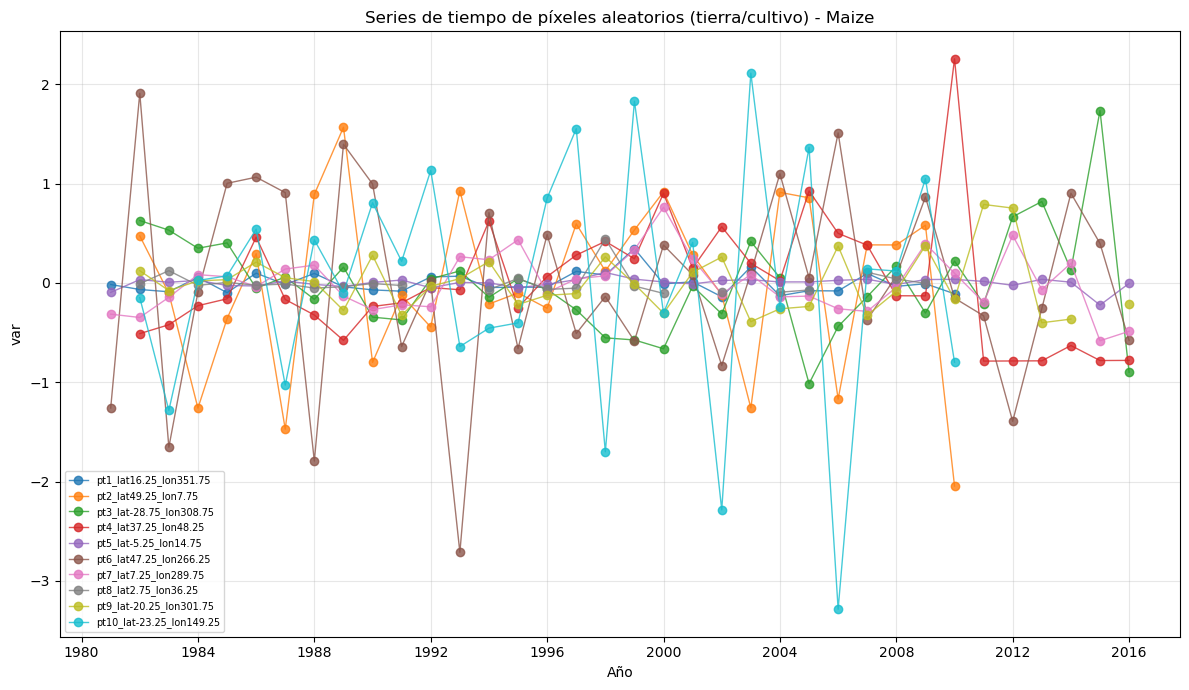

In [9]:
# ============================================================
#   SERIES DE TIEMPO DE PÍXELES ALEATORIOS (TIERRA/CULTIVO)
#   Usa GDHY (RAW o DETREND) y grafica N píxeles
#   Autor: Paola A. Ruiz Franco
# ============================================================

import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# ========= ARCHIVO DE CULTIVO ==========
# Puedes usar RAW o DETREND, según lo que quieras revisar
FILE = r"C:\Users\paola\Tesis\02_Procesados\GDHY_detrend\maize_yield_1981_2016_DETREND_clean.nc"
OUT_CSV = r"C:\Users\paola\Tesis\03_Resultados\Series_tiempo_pixeles"
os.makedirs(OUT_CSV, exist_ok=True)

ds = xr.open_dataset(FILE)
varname = list(ds.data_vars)[0]   # 'yield' o 'var'
da = ds[varname]

print(f"Variable: {varname}")
print(f"Dimensiones: {da.dims}")

# ========= MÁSCARA DE PÍXELES VÁLIDOS ==========
# Válidos = tienen al menos un valor no-NaN en el tiempo
mask_valid = np.isfinite(da).any(dim="time")

lats = ds.lat.values
lons = ds.lon.values

ii, jj = np.where(mask_valid.values == True)
print(f"Píxeles válidos (tierra/cultivo): {len(ii)}")

# ========= SELECCIONAR PUNTOS ALEATORIOS ==========
N = 10  # número de píxeles aleatorios que quieres mirar
N = min(N, len(ii))  # por si acaso

idx = np.random.choice(len(ii), size=N, replace=False)

# Guardamos info de los puntos
puntos = []
for k, idk in enumerate(idx):
    i = ii[idk]
    j = jj[idk]
    lat_k = lats[i]
    lon_k = lons[j]
    puntos.append((i, j, lat_k, lon_k))

print("\nPuntos seleccionados (idx_lat, idx_lon, lat, lon):")
for p in puntos:
    print(p)

# ========= EXTRAER SERIES DE TIEMPO Y GUARDAR EN CSV ==========
df = pd.DataFrame(index=pd.to_datetime(ds.time.values))

for k, (i, j, lat_k, lon_k) in enumerate(puntos):
    # CORRECTO: extraer por nombres de dimensión
    serie = da.isel(lat=i, lon=j).values

    col_name = f"pt{k+1}_lat{lat_k:.2f}_lon{lon_k:.2f}"
    df[col_name] = serie
    
# Guardar CSV
csv_file = os.path.join(OUT_CSV, "series_pixeles_aleatorios_maize.csv")
df.to_csv(csv_file)
print(f"\nCSV guardado en: {csv_file}")

# ========= GRAFICAR SERIES ==========
plt.figure(figsize=(12, 7))

for col in df.columns:
    plt.plot(df.index, df[col], marker='o', linewidth=1, alpha=0.8, label=col)

plt.xlabel("Año")
plt.ylabel(varname)
plt.title("Series de tiempo de píxeles aleatorios (tierra/cultivo) - Maize")
plt.grid(True, alpha=0.3)
plt.legend(fontsize=7, loc="best")
plt.tight_layout()
plt.show()


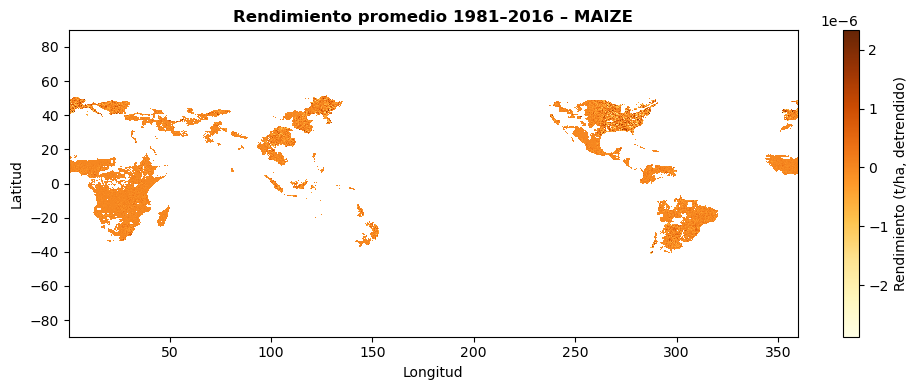

Mapa guardado en: C:\Users\paola\Tesis\03_Resultados\Mapas_rendimientos\maize_mapa_rendimiento.png


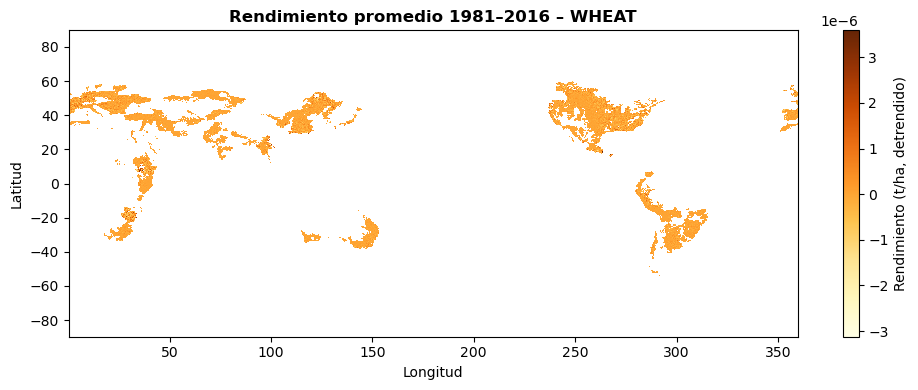

Mapa guardado en: C:\Users\paola\Tesis\03_Resultados\Mapas_rendimientos\wheat_mapa_rendimiento.png


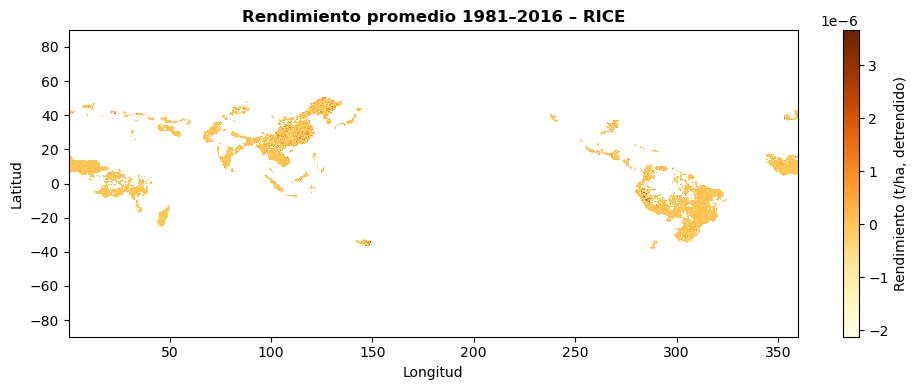

Mapa guardado en: C:\Users\paola\Tesis\03_Resultados\Mapas_rendimientos\rice_mapa_rendimiento.png


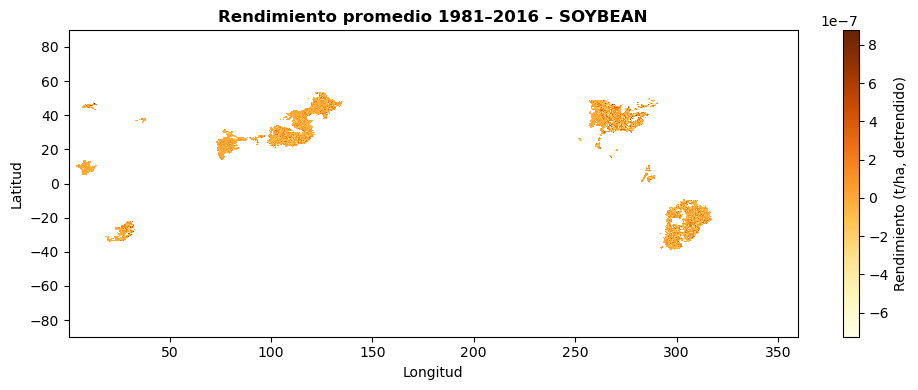

Mapa guardado en: C:\Users\paola\Tesis\03_Resultados\Mapas_rendimientos\soybean_mapa_rendimiento.png


In [14]:
# ============================================================
#   MAPAS 2D DE RENDIMIENTO PROMEDIO POR CULTIVO (lat vs lon)
#   Estilo EXACTO al ejemplo que mostraste
# ============================================================

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import os

BASE = r"C:\Users\paola\Tesis\02_Procesados\GDHY_detrend"
OUT  = r"C:\Users\paola\Tesis\03_Resultados\Mapas_rendimientos"
os.makedirs(OUT, exist_ok=True)

CULTIVOS = ["maize", "wheat", "rice", "soybean"]


def graficar_mapa_rendimiento(mapa, lat, lon, cultivo):
    """Genera mapa espacial del rendimiento promedio."""
    
    plt.figure(figsize=(10, 4))

    plt.imshow(
        mapa,
        origin="lower",
        extent=[lon.min(), lon.max(), lat.min(), lat.max()],
        cmap="YlOrBr",            # paleta estilo agricultura
        interpolation="nearest",
        aspect="auto"
    )

    plt.title(
        f"Rendimiento promedio 1981–2016 – {cultivo.upper()}",
        fontsize=12, fontweight="bold"
    )
    plt.xlabel("Longitud")
    plt.ylabel("Latitud")

    cbar = plt.colorbar()
    cbar.set_label("Rendimiento (t/ha, detrendido)", fontsize=10)

    plt.tight_layout()

    out_path = os.path.join(OUT, f"{cultivo}_mapa_rendimiento.png")
    plt.savefig(out_path, dpi=300)
    plt.show()
    print(f"Mapa guardado en: {out_path}")


# === Procesar cada cultivo ===
for cultivo in CULTIVOS:
    file = os.path.join(BASE, f"{cultivo}_yield_1981_2016_DETREND_clean.nc")
    ds = xr.open_dataset(file)
    varname = list(ds.data_vars)[0]
    da = ds[varname]

    # Promedio temporal → mapa (lat, lon)
    mapa = da.mean(dim="time").values
    
    graficar_mapa_rendimiento(
        mapa,
        ds.lat.values,
        ds.lon.values,
        cultivo
    )
